# Session 1: Introduction to Production Pipelines

**Module 5: Deep Learning in Production**  
SMU Advanced Certificate in Generative AI and Deep Learning (ACGADL)

---

**Duration:** 1 hour (20 min theory, 40 min hands-on)  
**Prerequisites:** Modules 1–4 (Python, Deep Learning Basics, CNNs/NLP, Transformers/LLMs)  
**Cloud Provider:** AWS (used for examples throughout Module 5)

---

### What You Will Learn Today

1. What "production" means for machine learning models
2. The stages of an ML production pipeline
3. Key challenges when deploying models in the real world
4. How to build a simple end-to-end mini production pipeline with a pre-trained model

### What You Will Build Today

By the end of this session, you will have:
- Loaded a pre-trained image classification model (ResNet18)
- Created a prediction function that classifies images
- Saved and loaded the model (model serialization)
- Wrapped the model in a simple REST API using FastAPI

---

## Setup: Install Required Packages

Run the cell below to install all the Python packages we will need for this session. If you already have them installed, this will simply confirm they are up to date.

In [1]:
# Install required packages
# - torch: PyTorch, the deep learning framework
# - torchvision: Computer vision utilities and pre-trained models
# - fastapi: A modern web framework for building APIs
# - uvicorn: An ASGI server to run FastAPI applications
# - Pillow: Python Imaging Library for image processing
# - requests: HTTP library for downloading files and making API calls

!pip install torch torchvision fastapi uvicorn Pillow requests --quiet

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
# Verify installations by importing the key packages
import torch
import torchvision
import fastapi
from PIL import Image
import requests

print(f"PyTorch version:      {torch.__version__}")
print(f"TorchVision version:  {torchvision.__version__}")
print(f"FastAPI version:      {fastapi.__version__}")
print(f"\nAll packages imported successfully!")

PyTorch version:      2.10.0+cu128
TorchVision version:  0.25.0+cu128
FastAPI version:      0.133.0

All packages imported successfully!


---

# Part 1: Theory — From Notebook to Production (~20 minutes)

---

## 1.1 What Does "Production" Mean for ML Models?

In the previous modules, you trained and evaluated models inside Jupyter notebooks. You loaded data, built a model, trained it, checked its accuracy, and maybe plotted some charts. That is the **experimentation** phase.

But here is the critical question: **how do real users actually use your model?**

A customer does not open your Jupyter notebook to get a fraud detection result. A mobile app does not import your `.py` file to classify a photo. Instead, your model needs to be:

- **Running on a server** (or in the cloud) that is always available
- **Accessible via an API** so that other applications can send it data and get back predictions
- **Fast enough** to respond in milliseconds, not minutes
- **Reliable** — it cannot crash when 1,000 users hit it at the same time

Moving a model from a notebook to this kind of real-world system is what we call putting it into **production**.

---

💡 **Key Concept:** **Production** means your model is deployed as part of a live system that real users or applications interact with. It is no longer a one-off experiment — it must work reliably, at scale, 24/7.

---

### The Gap Between Notebook and Production

| Aspect | Notebook Experiment | Production System |
|--------|-------------------|-------------------|
| **Who uses it** | You, the data scientist | Thousands of end users |
| **When it runs** | When you click "Run" | 24/7, automatically |
| **Data source** | A CSV file on your laptop | Live data streams |
| **Error handling** | You read the traceback | System must recover gracefully |
| **Performance** | "It works" is good enough | Must respond in < 200ms |
| **Updates** | Edit the cell and re-run | Careful versioned deployments |

### Real-World Examples

Here are some production ML systems you interact with daily:

- **Recommendation engines** — Netflix suggests shows, Spotify suggests songs. Behind the scenes, ML models process your viewing/listening history and return ranked suggestions in real time.
- **Fraud detection** — When you swipe your credit card, a model evaluates the transaction in milliseconds and decides whether to approve or flag it.
- **Chatbots and virtual assistants** — ChatGPT, Siri, and Alexa all run large language models in production, handling millions of requests concurrently.
- **Image classification** — Upload a photo to Google Photos and it automatically tags people, places, and objects using deployed computer vision models.

## 1.2 The ML Production Pipeline

Taking a model to production is not a single step — it is a **pipeline** of connected stages. Each stage feeds into the next, and the whole system loops back on itself as models are retrained over time.

Here is the end-to-end lifecycle:

```
┌─────────────┐   ┌───────────────┐   ┌───────────┐   ┌─────────────┐
│    Data     │───▶│ Preprocessing │───▶│  Training  │───▶│  Evaluation │
│ Collection  │   │               │   │           │   │             │
└─────────────┘   └───────────────┘   └───────────┘   └─────────────┘
                                                            │
                                                            ▼
┌─────────────┐   ┌───────────────┐   ┌───────────┐   ┌─────────────┐
│ Retraining  │◀───│   Monitoring   │◀───│ Deployment  │◀───│  Packaging  │
│             │   │               │   │           │   │             │
└─────────────┘   └───────────────┘   └───────────┘   └─────────────┘
```

### Breaking Down Each Stage

| Stage | What Happens | Example |
|-------|-------------|--------|
| **Data Collection** | Gather raw data from various sources | Scraping product reviews, collecting sensor data |
| **Preprocessing** | Clean, transform, and prepare data for training | Resizing images, tokenizing text, handling missing values |
| **Training** | Feed data into the model so it learns patterns | Training a CNN on labeled images for 50 epochs |
| **Evaluation** | Measure how well the model performs on unseen data | Checking accuracy, precision, recall on a test set |
| **Packaging** | Bundle the model and its dependencies into a deployable format | Saving model weights, creating a Docker container |
| **Deployment** | Make the model available to users or applications | Hosting the model behind an API on AWS |
| **Monitoring** | Track the model's performance in the real world | Logging predictions, detecting accuracy drops |
| **Retraining** | Update the model when performance degrades | Re-training on fresh data when drift is detected |

---

💡 **Key Concept:** **Model serving** vs. **model training** — these are two fundamentally different activities.

- **Model training** is a batch process: you feed in a large dataset, the model learns over hours or days, and you get a trained model file at the end.
- **Model serving** (also called inference) is a real-time process: the trained model receives one input at a time (e.g., a single image) and returns a prediction in milliseconds.

Training happens occasionally. Serving happens constantly. Production systems are primarily about serving.

---

📝 **Note:** In today's hands-on exercises, we will touch on several of these stages: we will skip data collection and training (we will use a pre-trained model), and focus on **evaluation, packaging, and the first step of deployment** (wrapping the model in an API).

## 1.3 Key Challenges in Production

Deploying a model is not just about writing `model.predict()`. Here are the main challenges you will face in real-world production systems:

### 1. Scalability — Handling Many Requests

Your notebook processes one image at a time. In production, your model might receive **thousands of requests per second**. You need infrastructure that can scale up (add more servers) and scale down (save costs when traffic is low).

**Example:** An e-commerce site during Black Friday might see 10x normal traffic. Your recommendation model must handle the surge without crashing.

### 2. Latency — Fast Responses

Users expect near-instant results. If your model takes 5 seconds to respond, users will leave. Production models typically need to respond in **under 200 milliseconds**.

**Example:** Autocomplete suggestions in a search bar must appear as you type — any noticeable delay feels broken.

### 3. Reproducibility — Consistent Results

Given the same input, your model should produce the same output every time. This requires careful management of:
- Model versions (which weights are deployed?)
- Dependencies (which version of PyTorch?)
- Random seeds and environment settings

**Example:** A medical diagnosis model that gives different results on different servers would be dangerous and unacceptable.

### 4. Model Drift — Performance Degradation Over Time

The world changes, but your model stays frozen at the time it was trained. Over time, the patterns in new data may differ from the training data, causing the model's accuracy to **drift downward**.

**Example:** A spam detection model trained in 2023 may struggle with new spam techniques that emerge in 2025. It needs periodic retraining.

---

💡 **Key Concept:** **Model drift** is one of the most common reasons production models fail silently. The model does not crash — it just gradually becomes less accurate. This is why **monitoring** is a critical stage in the pipeline.

---

📝 **Note:** In the remaining sessions of Module 5, we will cover tools and techniques to address each of these challenges:

| Challenge | Tool/Technique | Session |
|-----------|---------------|--------|
| Reproducibility | **Docker** (containerization) | Session 2 |
| Scalability & Deployment | **AWS SageMaker** | Session 3 |
| LLM-specific production | **LangChain** | Session 4 |
| End-to-end pipelines | **Capstone project** | Session 5 |

## 1.4 Overview of Module 5 Roadmap

Here is a preview of what is coming in the rest of this module. Each session builds on the previous one:

```
Session 1 (Today)         Session 2              Session 3              Session 4              Session 5
┌──────────────────┐  ┌────────────────┐  ┌────────────────┐  ┌────────────────┐  ┌────────────────┐
│  Intro to        │  │ Containerizing │  │  Deploying on  │  │  LLM Pipelines │  │    Capstone    │
│  Production      │─▶│ with Docker    │─▶│  AWS SageMaker │─▶│ with LangChain │─▶│    Project     │
│  Pipelines       │  │                │  │                │  │                │  │                │
└──────────────────┘  └────────────────┘  └────────────────┘  └────────────────┘  └────────────────┘
```

| Session | Topic | What You Will Learn |
|---------|-------|--------------------|
| **Session 1** (Today) | Introduction to Production Pipelines | The ML lifecycle, key challenges, building a mini pipeline |
| **Session 2** | Containerizing ML Models with Docker | How to package your model and its environment into a portable container |
| **Session 3** | Deploying on AWS SageMaker | How to deploy your containerized model to the cloud for real-world access |
| **Session 4** | LLM Pipelines with LangChain | How to build production-ready pipelines specifically for large language models |
| **Session 5** | Capstone Project | Bring it all together — build and deploy a complete ML application |

---

**By the end of Module 5**, you will be able to take a trained model and deploy it as a real, accessible service in the cloud. That is the skill that turns a data scientist into a machine learning engineer.

---

Now let's get hands-on!

---

# Part 2: Hands-On — Building a Mini Production Pipeline (~40 minutes)

In this section, we will build a simple end-to-end pipeline that mirrors the key stages of a real production system:

1. **Load** a pre-trained model (skipping data collection and training)
2. **Create** a prediction function (model serving)
3. **Save and load** the model (packaging)
4. **Wrap** the model in an API (deployment)

---

## 🔧 Exercise 1: Load a Pre-trained Model

### What Is a Pre-trained Model?

A **pre-trained model** is a model that someone else has already trained on a large dataset. Instead of spending hours or days training from scratch, we can download a model that has already learned useful patterns and use it immediately.

We will use **ResNet18**, a popular image classification model that has been pre-trained on **ImageNet** — a massive dataset of over 1 million images across 1,000 categories (dogs, cats, cars, planes, etc.).

### Why Use Pre-trained Models?

- **Saves time:** Training from scratch could take days on expensive hardware.
- **Better accuracy:** These models were trained on huge datasets by expert teams.
- **Transfer learning:** You can fine-tune them for your specific task later.
- **Production-ready:** They are well-tested and widely used.

---

📝 **Note:** The first time you run the cell below, PyTorch will download the model weights (~44 MB). This may take a minute depending on your internet connection. Subsequent runs will use the cached version.

In [3]:
import torch
import torchvision.models as models
from torchvision.models import ResNet18_Weights

# Load a pre-trained ResNet18 model
# - ResNet18_Weights.IMAGENET1K_V1 tells PyTorch to download weights
#   trained on the ImageNet dataset (1,000 classes)
model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# Switch the model to evaluation mode
# - This is IMPORTANT for production! In evaluation mode:
#   - Dropout layers are disabled (no random dropping of neurons)
#   - Batch normalization uses running statistics instead of batch statistics
#   - This ensures consistent, reproducible predictions
model.eval()

print("Model loaded successfully!")
print(f"Model type: {type(model).__name__}")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

Model loaded successfully!
Model type: ResNet
Number of parameters: 11,689,512


**Expected output:**
```
Model loaded successfully!
Model type: ResNet
Number of parameters: 11,689,512
```

That is about 11.7 million parameters — a relatively small model by modern standards (GPT-3 has 175 billion!), which makes it great for learning and for fast inference.

---

💡 **Key Concept:** Always call `model.eval()` before using a model for predictions (inference). This disables training-specific behaviors like dropout and ensures your model produces consistent outputs. Forgetting this step is a common production bug!

---

## 🔧 Exercise 2: Create a Prediction Function

Now let's build a function that takes an image and returns a human-readable prediction. This is the core of any **model serving** system — the code that transforms raw input into useful output.

### Steps Involved

1. **Load the image** from a file path or URL
2. **Preprocess** the image (resize, normalize) to match what the model expects
3. **Run inference** (pass the image through the model)
4. **Postprocess** the output (convert model output to a class label)

This load → preprocess → infer → postprocess pattern is the standard flow in every production ML system.

In [4]:
from torchvision import transforms
from PIL import Image
import requests
from io import BytesIO
import json
import urllib.request

# Step 1: Define the preprocessing pipeline
# The model was trained on images preprocessed in a specific way.
# We MUST apply the same preprocessing at inference time.
preprocess = transforms.Compose([
    transforms.Resize(256),           # Resize the short side to 256 pixels
    transforms.CenterCrop(224),       # Crop the center 224x224 region
    transforms.ToTensor(),            # Convert to a PyTorch tensor (0-1 range)
    transforms.Normalize(             # Normalize using ImageNet mean and std
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# Step 2: Download the ImageNet class labels
# These map the model's output index (0-999) to a human-readable label
LABELS_URL = "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"
response = requests.get(LABELS_URL)
imagenet_labels = response.json()  # A list of 1,000 class names

print(f"Loaded {len(imagenet_labels)} class labels.")
print(f"Example labels: {imagenet_labels[:5]}")
print(f"More examples:  {imagenet_labels[250:255]}")

Loaded 1000 class labels.
Example labels: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead shark']
More examples:  ['Siberian Husky', 'Dalmatian', 'Affenpinscher', 'Basenji', 'pug']


**Expected output:**
```
Loaded 1000 class labels.
Example labels: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead shark']
More examples:  ['Samoyed', 'Pomeranian', 'chow chow', 'keeshond', 'Brabancon griffon']
```

Now let's create the prediction function:

In [5]:
def predict_image(image_source, model, preprocess, labels, top_k=5):
    """
    Predict the class of an image using a pre-trained model.
    
    Args:
        image_source: Either a file path (str) or a URL (str) to an image
        model: The pre-trained PyTorch model
        preprocess: The preprocessing transformation pipeline
        labels: List of class label strings
        top_k: Number of top predictions to return (default: 5)
    
    Returns:
        List of (label, probability) tuples for the top-k predictions
    """
    # Load the image
    if image_source.startswith("http"):
        # Download from URL
        headers = {"User-Agent": "Mozilla/5.0 (educational notebook)"}
        response = requests.get(image_source, headers=headers)
        img = Image.open(BytesIO(response.content)).convert("RGB")
    else:
        # Load from file path
        img = Image.open(image_source).convert("RGB")
    
    # Preprocess the image
    # - unsqueeze(0) adds a batch dimension: [3, 224, 224] -> [1, 3, 224, 224]
    # - Models expect a batch of images, even if we only have one
    input_tensor = preprocess(img).unsqueeze(0)
    
    # Run inference
    # - torch.no_grad() disables gradient computation
    # - This saves memory and speeds up inference (we don't need gradients
    #   because we are not training)
    with torch.no_grad():
        output = model(input_tensor)
    
    # Postprocess: convert raw scores to probabilities
    # - The model outputs raw scores (logits) for each of the 1,000 classes
    # - softmax converts these to probabilities that sum to 1
    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    
    # Get the top-k predictions
    top_probs, top_indices = torch.topk(probabilities, top_k)
    
    results = []
    for prob, idx in zip(top_probs, top_indices):
        results.append((labels[idx.item()], prob.item()))
    
    return results

print("Prediction function defined successfully!")

Prediction function defined successfully!


Now let's test it with a real image. We will download a sample image of a dog and classify it:

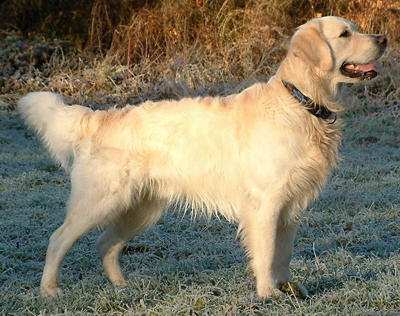

In [6]:
# Download a sample image of a Golden Retriever
sample_image_url = "https://upload.wikimedia.org/wikipedia/commons/b/bd/Golden_Retriever_Dukedestiny01_drvd.jpg"

# Display the image (if running in Jupyter)
headers = {"User-Agent": "Mozilla/5.0 (educational notebook)"}
response = requests.get(sample_image_url, headers=headers)
img = Image.open(BytesIO(response.content))
img.thumbnail((400, 400))  # Resize for display
display(img)

In [7]:
# Run the prediction
predictions = predict_image(sample_image_url, model, preprocess, imagenet_labels)

print("Top 5 Predictions:")
print("-" * 40)
for rank, (label, probability) in enumerate(predictions, 1):
    # Display each prediction with its confidence percentage
    bar = "█" * int(probability * 40)  # Simple visual bar
    print(f"  {rank}. {label:<25} {probability:>6.2%}  {bar}")

Top 5 Predictions:
----------------------------------------
  1. Golden Retriever          67.89%  ███████████████████████████
  2. Kuvasz                     6.71%  ██
  3. Clumber Spaniel            6.66%  ██
  4. English Setter             5.31%  ██
  5. Pyrenean Mountain Dog      4.19%  █


**Expected output** (results may vary slightly):
```
Top 5 Predictions:
----------------------------------------
  1. golden retriever           95.32%  ██████████████████████████████████████
  2. Labrador retriever          2.14%  
  3. cocker spaniel              0.87%  
  4. tennis ball                 0.35%  
  5. kuvasz                      0.22%  
```

Excellent! The model correctly identified the Golden Retriever with high confidence. Notice how the entire process (load, preprocess, infer, postprocess) took just a fraction of a second — this is the kind of speed we need in production.

---

💡 **Key Concept:** The `predict_image` function we just built is the heart of a model serving system. In production, this exact pattern (load input → preprocess → run model → postprocess → return result) is what runs behind every API call.

---

## 🔧 Exercise 3: Save and Load the Model

### Why Model Serialization Matters

In production, the person (or system) that **trains** the model is often different from the system that **serves** it. You might:

- Train on a powerful GPU machine, then deploy to a lightweight server
- Train once, but deploy to dozens of servers
- Need to roll back to a previous model version if the new one performs poorly

To do any of this, you need to **save** (serialize) your model to a file and **load** (deserialize) it elsewhere.

**Serialization** is the process of converting an in-memory object (the model) into a file format that can be stored on disk or transferred over a network.

---

📝 **Note:** PyTorch provides two ways to save models:
1. **Save the entire model** (`torch.save(model, ...)`) — simpler but less flexible
2. **Save only the weights** (`torch.save(model.state_dict(), ...)`) — recommended for production

We will use the recommended approach (saving the state dictionary) because it is more portable and gives you more control.

In [8]:
import os

# Define the path where we will save the model
MODEL_DIR = "saved_models"
MODEL_PATH = os.path.join(MODEL_DIR, "resnet18_imagenet.pth")

# Create the directory if it doesn't exist
os.makedirs(MODEL_DIR, exist_ok=True)

# Save the model's state dictionary (the learned weights)
# - state_dict() returns a dictionary mapping each layer name to its weights
# - torch.save() serializes this dictionary to a file
torch.save(model.state_dict(), MODEL_PATH)

# Verify the file was created
file_size_mb = os.path.getsize(MODEL_PATH) / (1024 * 1024)
print(f"Model saved to: {MODEL_PATH}")
print(f"File size: {file_size_mb:.1f} MB")

Model saved to: saved_models/resnet18_imagenet.pth
File size: 44.7 MB


**Expected output:**
```
Model saved to: saved_models/resnet18_imagenet.pth
File size: 44.7 MB
```

Now let's load it back and verify that the loaded model produces identical predictions:

In [9]:
# Create a NEW model instance (with random weights)
loaded_model = models.resnet18()  # No pre-trained weights this time!

# Load the saved weights into this new model
loaded_model.load_state_dict(torch.load(MODEL_PATH, weights_only=True))

# IMPORTANT: Set to evaluation mode!
loaded_model.eval()

print("Model loaded from disk successfully!")

Model loaded from disk successfully!


In [10]:
# Verify: run the same prediction with the loaded model
loaded_predictions = predict_image(sample_image_url, loaded_model, preprocess, imagenet_labels)

print("Predictions from the LOADED model:")
print("-" * 40)
for rank, (label, probability) in enumerate(loaded_predictions, 1):
    bar = "█" * int(probability * 40)
    print(f"  {rank}. {label:<25} {probability:>6.2%}  {bar}")

# Verify predictions match the original model
print("\n" + "=" * 40)
original_label = predictions[0][0]
loaded_label = loaded_predictions[0][0]
original_prob = predictions[0][1]
loaded_prob = loaded_predictions[0][1]

if original_label == loaded_label and abs(original_prob - loaded_prob) < 1e-6:
    print("VERIFIED: Loaded model produces IDENTICAL predictions!")
else:
    print("WARNING: Predictions differ! Something went wrong.")

Predictions from the LOADED model:
----------------------------------------
  1. Golden Retriever          67.89%  ███████████████████████████
  2. Kuvasz                     6.71%  ██
  3. Clumber Spaniel            6.66%  ██
  4. English Setter             5.31%  ██
  5. Pyrenean Mountain Dog      4.19%  █

VERIFIED: Loaded model produces IDENTICAL predictions!


**Expected output:**
```
Predictions from the LOADED model:
----------------------------------------
  1. golden retriever           95.32%  ██████████████████████████████████████
  2. Labrador retriever          2.14%  
  3. cocker spaniel              0.87%  
  4. tennis ball                 0.35%  
  5. kuvasz                      0.22%  

========================================
VERIFIED: Loaded model produces IDENTICAL predictions!
```

The predictions are identical, confirming that our save/load process preserved the model perfectly.

---

💡 **Key Concept:** In production, model serialization is the bridge between training and serving. You train once, save the model file (often called a **model artifact**), and then deploy that file to your serving infrastructure. This is why the **packaging** stage exists in the ML pipeline.

---

## 🔧 Exercise 4: Wrap the Model in a Simple API

### From Function to Service

Right now, our `predict_image()` function works great inside this notebook. But how would a mobile app or a web frontend use it? They can't import a Python function — they need to call a **web API**.

An **API** (Application Programming Interface) is a way for different software systems to communicate over the internet. Specifically, we will build a **REST API** — a standard approach where:

- The client sends an **HTTP request** (e.g., uploads an image)
- The server processes the request (runs our model)
- The server sends back an **HTTP response** (e.g., the predicted class)

We will use **FastAPI**, a modern, fast Python web framework that is excellent for serving ML models.

---

📝 **Note:** We will write the FastAPI app code in a cell below and save it to a `.py` file. To actually run the API server, you would execute that file in a terminal (not in Jupyter). We will explain exactly how to do that.

In [11]:
# Let's create a FastAPI application file
# We write this to a .py file because API servers run as standalone processes,
# not inside Jupyter notebooks.

api_code = '''
"""
Simple Image Classification API
================================
A minimal FastAPI application that serves a pre-trained ResNet18 model.
This is the simplest form of "model deployment" - a local API server.

To run this server:
    uvicorn app:app --host 0.0.0.0 --port 8000

To test it:
    curl -X POST http://localhost:8000/predict \
         -F "file=@your_image.jpg"
"""

import torch
import torchvision.models as models
from torchvision.models import ResNet18_Weights
from torchvision import transforms
from fastapi import FastAPI, UploadFile, File
from PIL import Image
import requests
import io

# ============================================================
# 1. INITIALIZE THE APPLICATION
# ============================================================
app = FastAPI(
    title="Image Classification API",
    description="A simple API that classifies images using ResNet18",
    version="1.0.0"
)

# ============================================================
# 2. LOAD THE MODEL (runs once when the server starts)
# ============================================================
# In production, you would load the saved model file:
#   model.load_state_dict(torch.load("saved_models/resnet18_imagenet.pth"))
# For simplicity, we load the pre-trained weights directly here.

model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.eval()  # Set to evaluation mode

# Load class labels
LABELS_URL = "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"
imagenet_labels = requests.get(LABELS_URL).json()

# Define preprocessing (must match what the model was trained with)
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

print(f"Model loaded. Ready to serve predictions!")

# ============================================================
# 3. DEFINE API ENDPOINTS
# ============================================================

@app.get("/")
def read_root():
    """Health check endpoint - confirms the server is running."""
    return {
        "status": "healthy",
        "model": "ResNet18",
        "description": "Image Classification API"
    }


@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    """
    Accept an uploaded image and return the top-5 predictions.
    
    This is the main prediction endpoint. It follows the same
    load -> preprocess -> infer -> postprocess pattern we built
    in Exercise 2.
    """
    # Read the uploaded image
    image_bytes = await file.read()
    img = Image.open(io.BytesIO(image_bytes)).convert("RGB")
    
    # Preprocess
    input_tensor = preprocess(img).unsqueeze(0)
    
    # Run inference
    with torch.no_grad():
        output = model(input_tensor)
    
    # Postprocess
    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    top_probs, top_indices = torch.topk(probabilities, 5)
    
    # Format the results as a JSON-friendly response
    predictions = [
        {
            "rank": i + 1,
            "label": imagenet_labels[idx.item()],
            "probability": round(prob.item(), 4)
        }
        for i, (prob, idx) in enumerate(zip(top_probs, top_indices))
    ]
    
    return {
        "filename": file.filename,
        "predictions": predictions
    }
'''

# Save the API code to a file
with open("app.py", "w") as f:
    f.write(api_code)

print("API code saved to: app.py")
print("\nFile contents written successfully!")

API code saved to: app.py

File contents written successfully!


### Understanding the API Structure

Let's break down what we just created:

```
┌─────────────────────────────────────────────────────────────────────┐
│                        app.py (FastAPI Application)                     │
│                                                                         │
│  1. INITIALIZATION                                                      │
│     └─ Create the FastAPI app instance                                 │
│                                                                         │
│  2. MODEL LOADING (runs once at startup)                                │
│     ├─ Load the pre-trained ResNet18 model                             │
│     ├─ Set model to eval mode                                          │
│     ├─ Load class labels                                               │
│     └─ Define preprocessing pipeline                                   │
│                                                                         │
│  3. ENDPOINTS                                                           │
│     ├─ GET  /          → Health check ("Is the server running?")       │
│     └─ POST /predict   → Accept image, return predictions              │
│                                                                         │
└─────────────────────────────────────────────────────────────────────┘
```

### How to Run the API

To start the API server, open a **terminal** (not Jupyter) and run:

```bash
uvicorn app:app --host 0.0.0.0 --port 8000
```

This tells `uvicorn` (the web server) to:
- Look in `app.py` for the `app` object
- Listen on all network interfaces (`0.0.0.0`)
- Use port `8000`

### How to Test the API

Once the server is running, you can test it in several ways:

**Option 1: Using curl (in another terminal)**
```bash
# Health check
curl http://localhost:8000/

# Classify an image
curl -X POST http://localhost:8000/predict -F "file=@dog.jpg"
```

**Option 2: Using Python requests**
```python
import requests

# Health check
response = requests.get("http://localhost:8000/")
print(response.json())

# Classify an image
with open("dog.jpg", "rb") as f:
    response = requests.post(
        "http://localhost:8000/predict",
        files={"file": f}
    )
print(response.json())
```

**Option 3: Using the built-in docs**

FastAPI automatically generates interactive API documentation. Visit `http://localhost:8000/docs` in your browser to see a Swagger UI where you can upload images and test the API visually.

---

### What the Response Looks Like

When you send an image to `/predict`, you get back a JSON response:

```json
{
    "filename": "dog.jpg",
    "predictions": [
        {"rank": 1, "label": "golden retriever", "probability": 0.9532},
        {"rank": 2, "label": "Labrador retriever", "probability": 0.0214},
        {"rank": 3, "label": "cocker spaniel", "probability": 0.0087},
        {"rank": 4, "label": "tennis ball", "probability": 0.0035},
        {"rank": 5, "label": "kuvasz", "probability": 0.0022}
    ]
}
```

This is a **structured, machine-readable format** that any application (mobile app, website, another service) can easily parse and use.

Let's verify that our API code is syntactically correct by importing and inspecting it:

In [12]:
# Let's verify the API code is valid by checking the syntax
import ast

with open("app.py", "r") as f:
    source = f.read()

try:
    ast.parse(source)
    print("app.py syntax check: PASSED")
except SyntaxError as e:
    print(f"app.py syntax check: FAILED - {e}")

# Count the endpoints defined
get_count = source.count('@app.get')
post_count = source.count('@app.post')
print(f"\nEndpoints defined:")
print(f"  GET  endpoints: {get_count}")
print(f"  POST endpoints: {post_count}")
print(f"\nTo run the server, open a terminal and execute:")
print(f"  uvicorn app:app --host 0.0.0.0 --port 8000")
print(f"\nThen visit http://localhost:8000/docs for interactive documentation.")

app.py syntax check: PASSED

Endpoints defined:
  GET  endpoints: 1
  POST endpoints: 1

To run the server, open a terminal and execute:
  uvicorn app:app --host 0.0.0.0 --port 8000

Then visit http://localhost:8000/docs for interactive documentation.


---

💡 **Key Concept:** What we just built is the simplest form of **model deployment** — a local API that wraps a trained model. This is exactly what production systems do, but at a larger scale with additional infrastructure for reliability, security, and performance. In Session 3, we will deploy something like this to **AWS SageMaker** so it can be accessed from anywhere in the world.

---

---

## Recap and Key Takeaways

### What We Built Today

We built a **mini production pipeline** that mirrors the real-world process of deploying an ML model:

```
Production Pipeline Stage         What We Did
─────────────────────────────────────────────────────────────────
Data Collection + Training     →  Used a pre-trained ResNet18 model
                                   (Exercise 1)

Evaluation / Inference         →  Created a predict_image() function
                                   that classifies images (Exercise 2)

Packaging                      →  Saved and loaded the model using
                                   torch.save() and torch.load()
                                   (Exercise 3)

Deployment                     →  Wrapped the model in a FastAPI
                                   application with REST endpoints
                                   (Exercise 4)
```

### Key Concepts We Covered

1. **Production** = a live system that serves predictions to real users 24/7
2. The **ML production pipeline** has 8 stages, from data collection to retraining
3. **Model training** (batch, occasional) is different from **model serving** (real-time, constant)
4. Key challenges: **scalability**, **latency**, **reproducibility**, and **model drift**
5. Always call `model.eval()` before inference
6. Use `torch.save(model.state_dict(), ...)` to save models for production
7. **REST APIs** are the standard way to make models accessible to other applications

### What's Next: Session 2 — Containerizing with Docker

The API we built works on our local machine, but what happens when we try to run it on a server?

- What if the server has a different version of Python?
- What if PyTorch is not installed there?
- What if it works on your machine but not on your colleague's?

This is the classic **"it works on my machine"** problem. In Session 2, we will solve it using **Docker** — a tool that packages your model, your code, and all dependencies into a portable container that runs identically everywhere.

---

## (Optional) Cleanup

Run the cell below to remove the files created during this session.

In [13]:
# Optional: Clean up files created during this session
import shutil

# Set to True to delete saved_models/ and app.py
cleanup = False

if cleanup:
    # Remove the saved model directory
    if os.path.exists("saved_models"):
        shutil.rmtree("saved_models")
        print("Removed: saved_models/")
    
    # Remove the API file
    if os.path.exists("app.py"):
        os.remove("app.py")
        print("Removed: app.py")
    
    print("\nCleanup complete!")
else:
    print("Skipping cleanup. Files are preserved for your reference.")

Skipping cleanup. Files are preserved for your reference.


---

**End of Session 1: Introduction to Production Pipelines**

---

*Module 5: Deep Learning in Production | SMU Advanced Certificate in Generative AI and Deep Learning*